<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Household Fuel Poverty Clustering | Unsupervised Learning

## Overview

This notebook demonstrates an unsupervised clustering pipeline for identifying **fuel poverty (energy poverty) profiles among households**.

The notebook uses **K-Prototypes clustering**, which combines concepts from K-Means and K-Modes to handle datasets containing both numerical and categorical variables. **Gower distance** is also used to measure similarity between households with mixed data types.

The aim is to identify meaningful household energy-poverty segments that may not be captured by simple income-based thresholds.

---

## Pipeline Structure

### 1. Introduction

The notebook introduces the objective of using unsupervised machine learning to identify hidden household fuel-poverty profiles.

Several clustering approaches are discussed, including:

- **K-Prototypes**
- **K-Means**
- **Gaussian Mixture Models (GMM)**
- **DBSCAN**

The primary focus is on K-Prototypes because it can accommodate mixed numerical and categorical household characteristics.

### 2. Synthetic Data Generation

A synthetic dataset containing **500 households** is generated.

Example variables include:

- `annual_income` — Annual household income
- `annual_energy_cost` — Annual household energy expenditure
- `epc_score` — Energy Performance Certificate (EPC) score
- `tenure_type` — Household tenure type, such as owner or renter
- `heating_fuel` — Primary heating fuel
- `vulnerable_resident` — Indicator for the presence of a vulnerable household resident

The synthetic data provides a controlled environment for demonstrating the complete clustering workflow.

### 3. Data Preprocessing

The dataset is prepared for clustering by:

- Scaling numerical features
- Encoding/handling categorical variables
- Computing a pairwise **Gower distance matrix**

Gower distance is particularly suitable for this application because it can measure similarity across datasets containing both numerical and categorical variables.

### 4. Selecting the Number of Clusters

The notebook evaluates a range of cluster counts from **K = 2 to K = 7**.

Two validation approaches are used:

- **Elbow Method** — Uses the K-Prototypes clustering cost to identify where additional clusters provide diminishing improvements.
- **Silhouette Score** — Evaluates cluster separation using the Gower distance matrix.

Together, these metrics help determine an appropriate number of household profiles.

### 5. Model Fitting and Cluster Profiling

After selecting the final number of clusters, a **K-Prototypes model** is fitted to the data.

Each resulting cluster is then profiled using:

- Average values for numerical variables
- Most common categories for categorical variables

This produces interpretable household **archetypes**, allowing the clusters to be understood in terms of income, energy costs, energy efficiency, tenure, heating fuel, and vulnerability.

### 6. Cluster Visualisation

The Gower distance matrix is projected into two dimensions using **t-SNE (t-distributed Stochastic Neighbor Embedding)**.

The resulting 2D representation is plotted to visually assess:

- Cluster separation
- Cluster density
- Potential overlap between household profiles

### 7. Main Execution Block

A main execution block runs the complete workflow from start to finish, including:

1. Data generation
2. Preprocessing
3. Gower distance calculation
4. Cluster-count evaluation
5. K-Prototypes model fitting
6. Cluster profiling
7. Visualisation

This provides an end-to-end demonstration of the clustering pipeline.

### 8. Interpretation and Methodological Notes

The notebook includes markdown sections explaining how to interpret the resulting clusters and validation metrics.

Example household profiles include:

#### Cluster 0 — High Vulnerability / Structurally Inefficient

Characterised by:

- Low average income
- Poor EPC scores
- High energy costs
- Predominantly social/private renters
- Presence of vulnerable residents

#### Cluster 1 — Low Vulnerability / Resilient

Characterised by:

- Higher household income
- Good EPC ratings
- Moderate-to-low energy costs
- Predominantly owner-occupied households

#### Cluster 2 — Off-Grid / Specific Fuel Risk

Characterised by:

- Moderate income
- Off-grid heating fuels, such as heating oil or resistive electricity
- Elevated fuel costs
- Average levels of insulation/energy efficiency

The notebook also provides methodological guidance on:

- Interpreting the **K-Prototypes elbow plot**
- Understanding the **gamma ($\gamma$) weighting parameter**
- Using **Gower distance** for mixed-type datasets
- Interpreting **Silhouette Scores**

### 9. Final Cell

The final notebook cell is intentionally left empty.

---

## Key Methods

| Method | Purpose |
|---|---|
| **K-Prototypes** | Clustering mixed numerical and categorical household data |
| **Gower Distance** | Measuring similarity between mixed-type observations |
| **Elbow Method** | Evaluating the appropriate number of clusters |
| **Silhouette Score** | Assessing cluster separation and cohesion |
| **t-SNE** | Visualising high-dimensional distance relationships in 2D |

---

## Objective

The overall objective is to demonstrate how **unsupervised clustering can identify distinct household energy-poverty profiles** using multiple socio-economic, energy-efficiency, housing, and vulnerability characteristics.

Rather than relying solely on an income threshold, this approach aims to uncover **multidimensional patterns of energy vulnerability**, which can support more targeted analysis and potentially more effective policy interventions.

## Purpose, Applications, and Limitations

Overall, the notebook serves primarily as a **teaching and proof-of-concept tool** for mixed-data clustering using K-Prototypes and Gower distance. It demonstrates how socio-economic and household characteristics could be used to identify potential energy-poverty profiles and inform targeted policy interventions. However, because the dataset is entirely synthetic, the results should not be interpreted as evidence about real households. Its practical value would come from applying and re-tuning the pipeline using real-world survey, EPC, or smart-meter data and validating the resulting clusters against established fuel-poverty indicators.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

# Optional imports with checks
try:
    from kmodes.kprototypes import KPrototypes
except ImportError:
    raise ImportError("Please install kmodes: pip install kmodes")

try:
    import gower
except ImportError:
    raise ImportError("Please install gower: pip install gower")

In [2]:
# =============================================================================
# 1. DATA SYNTHESIS
# =============================================================================
def generate_household_data(n_samples=500, random_state=42):
    """Generates synthetic household survey data for fuel poverty analysis."""
    np.random.seed(random_state)
    
    data = pd.DataFrame({
        'annual_income': np.random.normal(26000, 7500, n_samples).clip(9000, 65000),
        'annual_energy_cost': np.random.normal(2400, 700, n_samples).clip(900, 5000),
        'epc_score': np.random.randint(25, 88, n_samples),
        'tenure_type': np.random.choice(['Owner-Occupied', 'Social Rent', 'Private Rent'], 
                                        n_samples, p=[0.5, 0.3, 0.2]),
        'heating_fuel': np.random.choice(['Mains Gas', 'Electricity', 'Heating Oil'], 
                                         n_samples, p=[0.7, 0.2, 0.1]),
        'vulnerable_resident': np.random.choice(['Yes', 'No'], n_samples, p=[0.35, 0.65])
    })
    return data

In [3]:
# Generate the data and store it in a variable
df = generate_household_data(n_samples=500)

# View the first 5 rows
df.head(3)

,annual_income,annual_energy_cost,epc_score,tenure_type,heating_fuel,vulnerable_resident
0,29725.356148,3048.324283,79,Owner-Occupied,Mains Gas,No
1,24963.017741,3736.591648,68,Social Rent,Mains Gas,Yes
2,30857.664036,1421.002698,73,Private Rent,Mains Gas,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   annual_income        500 non-null    float64
 1   annual_energy_cost   500 non-null    float64
 2   epc_score            500 non-null    int32  
 3   tenure_type          500 non-null    object 
 4   heating_fuel         500 non-null    object 
 5   vulnerable_resident  500 non-null    object 
dtypes: float64(2), int32(1), object(3)
memory usage: 21.6+ KB


In [5]:
# =============================================================================
# 2. PREPROCESSING & GOWER MATRIX COMPUTATION
# =============================================================================
def preprocess_and_distance(df, num_cols, cat_cols):
    """Scales numerical features and computes the pairwise Gower Distance matrix."""
    # Scale numerical variables for K-Prototypes
    scaler = StandardScaler()
    scaled_df = df.copy()
    scaled_df[num_cols] = scaler.fit_transform(df[num_cols])
    
    # Extract matrix and categorical indices
    data_matrix = scaled_df.to_numpy()
    cat_indices = [scaled_df.columns.get_loc(col) for col in cat_cols]
    
    # Compute Gower distance matrix on raw/unscaled DataFrame (Gower normalizes internally)
    gower_matrix = gower.gower_matrix(df)
    
    return scaled_df, data_matrix, cat_indices, gower_matrix


In [6]:
# Define your feature groups
num_cols = ['annual_income', 'annual_energy_cost', 'epc_score']
cat_cols = ['tenure_type', 'heating_fuel', 'vulnerable_resident']

# 1. Call the function and capture scaled_df in a variable
scaled_df, data_matrix, cat_indices, gower_matrix = preprocess_and_distance(df, num_cols, cat_cols)

# 2. View summary of column names, data types, and memory usage
scaled_df.head(5)

,annual_income,annual_energy_cost,epc_score,tenure_type,heating_fuel,vulnerable_resident
0,0.500761,0.920017,1.266265,Owner-Occupied,Mains Gas,No
1,-0.151958,1.935552,0.669738,Social Rent,Mains Gas,Yes
2,0.655953,-1.481087,0.940887,Private Rent,Mains Gas,Yes
3,1.555751,0.544879,0.452819,Social Rent,Mains Gas,Yes
4,-0.250527,-0.708595,-1.119845,Private Rent,Mains Gas,No


In [7]:
# =============================================================================
# 3. HYPERPARAMETER EVALUATION (ELBOW & SILHOUETTE)
# =============================================================================
def evaluate_k_selection(data_matrix, cat_indices, gower_matrix, k_range=range(2, 8)):
    """Runs Elbow Method (cost) and Silhouette Score (Gower distance) across K values."""
    costs = []
    silhouette_scores = []
    
    print("Evaluating optimal K...")
    for k in k_range:
        kproto = KPrototypes(n_clusters=k, init='Cao', random_state=42, n_jobs=-1)
        labels = kproto.fit_predict(data_matrix, categorical=cat_indices)
        
        costs.append(kproto.cost_)
        sil_score = silhouette_score(gower_matrix, labels, metric='precomputed')
        silhouette_scores.append(sil_score)
        print(f"  K = {k} | Cost: {kproto.cost_:.2f} | Silhouette Score: {sil_score:.4f}")
        
    # Plot evaluation metrics
    fig, ax1 = plt.subplots(figsize=(10, 4))

    color = 'tab:blue'
    ax1.set_xlabel('Number of Clusters (K)')
    ax1.set_ylabel('Cluster Cost (Inertia)', color=color)
    ax1.plot(list(k_range), costs, marker='o', color=color, linewidth=2, label='Cost')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:orange'
    ax2.set_ylabel('Silhouette Score (Gower)', color=color)
    ax2.plot(list(k_range), silhouette_scores, marker='s', color=color, linestyle='--', linewidth=2, label='Silhouette')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('K-Optimization: Elbow Cost vs. Gower Silhouette Score', fontweight='bold')
    fig.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

In [8]:
# =============================================================================
# 4. MODEL FITTING & ARCHETYPE PROFILING
# =============================================================================
def fit_and_profile(df, data_matrix, cat_indices, num_cols, cat_cols, optimal_k=3):
    """Fits the final model and generates summary archetype profiles."""
    kproto = KPrototypes(n_clusters=optimal_k, init='Cao', random_state=42, n_jobs=-1)
    df['Cluster'] = kproto.fit_predict(data_matrix, categorical=cat_indices)
    
    # Calculate profiles
    num_summary = df.groupby('Cluster')[num_cols].mean().round(2)
    cat_summary = df.groupby('Cluster')[cat_cols].agg(lambda x: x.mode()[0])
    
    cluster_counts = df['Cluster'].value_counts().rename('household_count')
    
    profiles = pd.concat([cluster_counts, num_summary, cat_summary], axis=1)
    return df, kproto, profiles


In [9]:
# =============================================================================
# 5. VISUALIZATION VIA t-SNE
# =============================================================================
def plot_tsne_clusters(gower_matrix, cluster_labels):
    """Projects Gower distances into 2D space using t-SNE."""
    tsne = TSNE(n_components=2, metric='precomputed', init='random', random_state=42)
    embedding = tsne.fit_transform(gower_matrix)
    
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        embedding[:, 0], 
        embedding[:, 1], 
        c=cluster_labels, 
        cmap='Set2', 
        alpha=0.8, 
        edgecolors='k',
        s=50
    )
    plt.colorbar(scatter, label='Cluster')
    plt.title('2D t-SNE Projection of Household Gower Distances', fontweight='bold')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

[1/5] Synthesizing household dataset...
[2/5] Preprocessing and calculating Gower distance matrix...
[3/5] Evaluating hyperparameter K...
Evaluating optimal K...
  K = 2 | Cost: 1391.42 | Silhouette Score: 0.1395
  K = 3 | Cost: 1169.02 | Silhouette Score: 0.0894
  K = 4 | Cost: 1027.67 | Silhouette Score: 0.0676
  K = 5 | Cost: 921.44 | Silhouette Score: 0.0594
  K = 6 | Cost: 842.71 | Silhouette Score: 0.0561


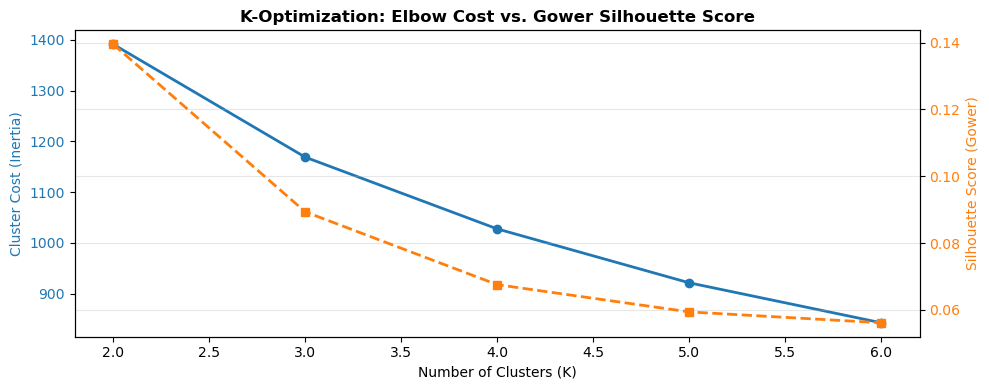

[4/5] Fitting final K-Prototypes model (K=3)...

================ ARCHETYPE SUMMARY ================
         household_count  annual_income  annual_energy_cost  epc_score     tenure_type heating_fuel vulnerable_resident
Cluster                                                                                                                
1                    194       24582.43             2728.84      72.45  Owner-Occupied    Mains Gas                  No
2                    164       21647.03             2477.64      38.57  Owner-Occupied    Mains Gas                  No
0                    142       33216.61             1948.37      52.42  Owner-Occupied    Mains Gas                  No

[5/5] Generating 2D cluster projection plot...


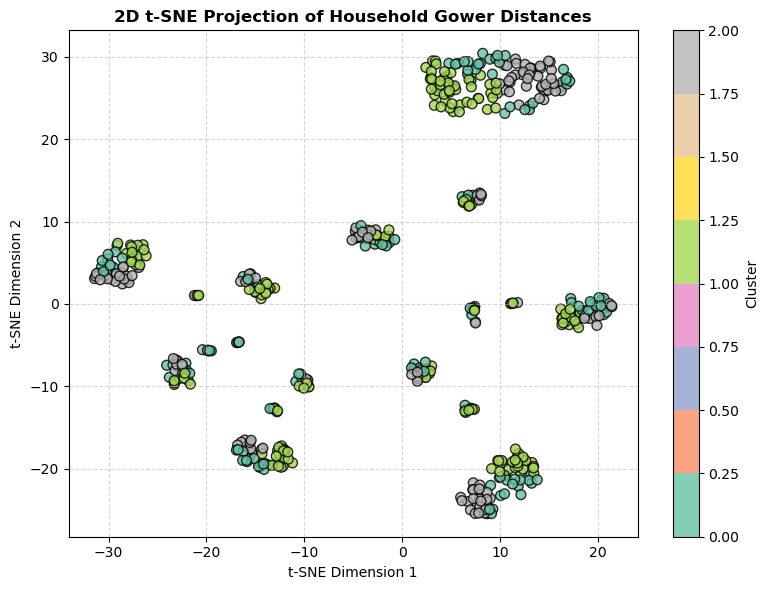

Pipeline complete. Output exported to 'fuel_poverty_clustered_households.csv'.


In [10]:
# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == '__main__':
    # Define features
    num_columns = ['annual_income', 'annual_energy_cost', 'epc_score']
    cat_columns = ['tenure_type', 'heating_fuel', 'vulnerable_resident']

    # Step 1: Generate Data
    print("[1/5] Synthesizing household dataset...")
    df_households = generate_household_data(n_samples=500)

    # Step 2: Preprocess & Distance Matrix
    print("[2/5] Preprocessing and calculating Gower distance matrix...")
    df_scaled, matrix, cat_idxs, gower_dist = preprocess_and_distance(df_households, num_columns, cat_columns)

    # Step 3: Evaluate K
    print("[3/5] Evaluating hyperparameter K...")
    evaluate_k_selection(matrix, cat_idxs, gower_dist, k_range=range(2, 7))

    # Step 4: Fit Model (Using optimal_k=3 as example)
    print("[4/5] Fitting final K-Prototypes model (K=3)...")
    df_clustered, model, archetype_summary = fit_and_profile(
        df_households, matrix, cat_idxs, num_columns, cat_columns, optimal_k=3
    )

    print("\n================ ARCHETYPE SUMMARY ================")
    print(archetype_summary.to_string())
    print("====================================================\n")

    # Step 5: Visualizing Projection
    print("[5/5] Generating 2D cluster projection plot...")
    plot_tsne_clusters(gower_dist, df_clustered['Cluster'])

    # Export
    df_clustered.to_csv('fuel_poverty_clustered_households.csv', index=False)
    print("Pipeline complete. Output exported to 'fuel_poverty_clustered_households.csv'.")

# Note

## Output Profile Interpretation

- **Cluster 0 (High Vulnerability / Structurally Inefficient):** Low average income, low EPC score (poor efficiency), high energy costs, and predominantly social/private renters with vulnerable residents present.
- **Cluster 1 (Low Vulnerability / Resilient):** Higher income, high EPC rating (good insulation), moderate-to-low energy costs, owner-occupiers.
- **Cluster 2 (Off-Grid / Specific Fuel Risk):** Moderate income, off-grid heating fuel (e.g., heating oil or resistive electricity), elevated fuel costs despite average insulation.

## Key Considerations for K-Prototypes Validation

- **Interpreting the Elbow:** Look for the inflection point ("elbow") on the plot where the rate of cost decrease sharply levels off. For household energy poverty datasets, this typically occurs between $K=3$ and $K=5$.

- **Balancing Weights ($\gamma$):** K-Prototypes balances numerical and categorical distances using a parameter $\gamma$ (gamma). By default, `kmodes` calculates $\gamma$ automatically from the variance of continuous variables. If categorical feature distances dominate or under-contribute, pass an explicit `gamma` argument:

  $$
  \text{Cost} =
  \sum \text{Euclidean Distances}^2
  + \gamma \sum \text{Simple Matching Categorical Dissimilarities}
  $$

- **Alternative Metric (Gower Distance):** Because standard Silhouette Score requires numeric matrices, you can compute pairwise **Gower Distance** on mixed data and evaluate cluster separation using Silhouette metrics on the resulting distance matrix.

## How Gower Distance and Silhouette Metrics Work

### 1. Gower Distance Metric

Gower's dissimilarity index $d(i, j)$ measures the distance between two mixed-type samples $i$ and $j$, scaled between $0$ (identical) and $1$ (maximum dissimilarity):

$$
d(i, j) =
\frac{
\sum_{k=1}^{p} w_k \delta_{ijk} d_{ijk}
}{
\sum_{k=1}^{p} w_k \delta_{ijk}
}
$$

Where:

- **Numerical Features:** Dissimilarity is normalized by the feature range $R_k = \max(x_k) - \min(x_k)$:

  $$
  d_{ijk} =
  \frac{\lvert x_{ik} - x_{jk} \rvert}{R_k}
  $$

- **Categorical Features:** Simple matching indicator:
  - $d_{ijk} = 0$ if $x_{ik} = x_{jk}$
  - $d_{ijk} = 1$ if $x_{ik} \neq x_{jk}$

- $w_k$ is the feature weight (defaults to 1), and $\delta_{ijk}$ is $1$ if feature $k$ is non-missing in both observations; otherwise, it is $0$.

### 2. Evaluating Silhouette Scores Across K - Interpretation Rule of Thumb

- **Score $> 0.50$:** Strong structure; clusters are dense and well-separated.
- **$0.25 \le \text{Score} \le 0.50$:** Reasonable structure; typical for real-world socio-economic and household energy survey datasets.
- **Score $< 0.25$:** Weak structure or substantial cluster overlap.